# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 20    |  |
| :-------------|:-------------|
| Félicie van der Leij| 6210392 |
| Luc van der Wilt| 6430589 |
| Erik van den Berg | 6328407 | 

In [61]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Erik van den Berg','Félicie van der Leij','Luc van der Wilt']

## Opdracht 1: Planning.

| Planning Groep: 20     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Calibratie en testen van meetopstelling |
| Mijlpaal 2 | Algoritme en iteratie |
| groep aanwezig 1| Ja |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:30-15:40 |

## Opdracht 2: Import libs.

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="IMG_5414.JPG" width="400">

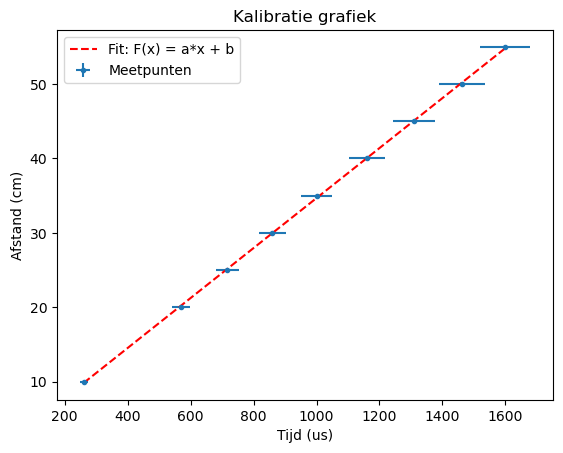

a = 0.033591828535943336
b = 1.084026280767008


In [41]:
# verwerk hier jullie kalibratiemetingen
Afstand = np.array([10,20,25,30,35,40,45,50,55]) #cm
Tijd = np.array([260,570,717,860,1000,1160,1310,1461,1600]) #us

from scipy.optimize import curve_fit 

def func1(x,a,b):
	return a*x + b

popt,pcov = curve_fit(func1,Tijd,Afstand)

x = np.linspace(min(Tijd),max(Tijd),1000)
y = func1(x,*popt)

plt.figure()
plt.errorbar(Tijd,Afstand, xerr=0.05*Tijd, yerr=1e-3, fmt=".", label="Meetpunten")
plt.plot(x,y, "r--", label="Fit: F(x) = a*x + b")
plt.ylabel("Afstand (cm)")
plt.xlabel("Tijd (us)")
plt.title("Kalibratie grafiek")
plt.legend()
plt.show()

print("a =", popt[0])
print("b =", popt[1])

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  42.2
1   0  30   0  20  42.3
2  40   0  30   0  41.7
3  30   0  20   0  41.6


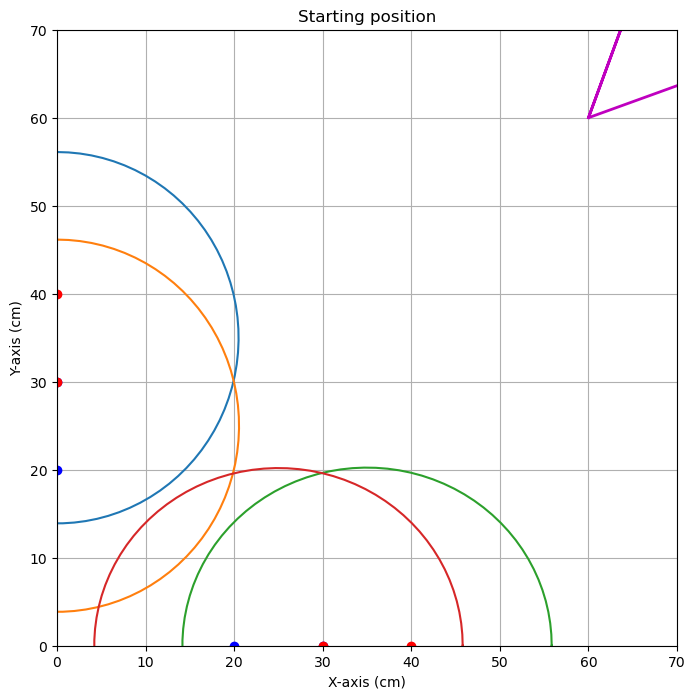


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.005


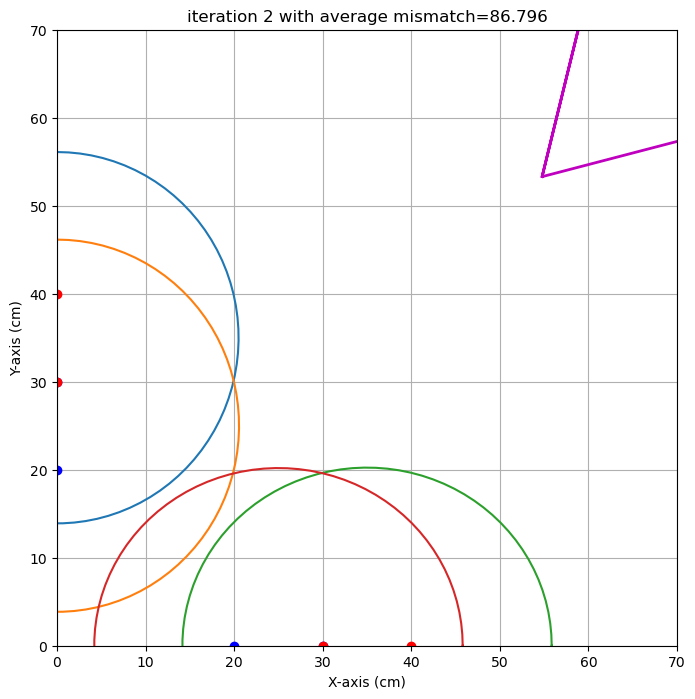

end iteration 2 with average mismatch=86.796


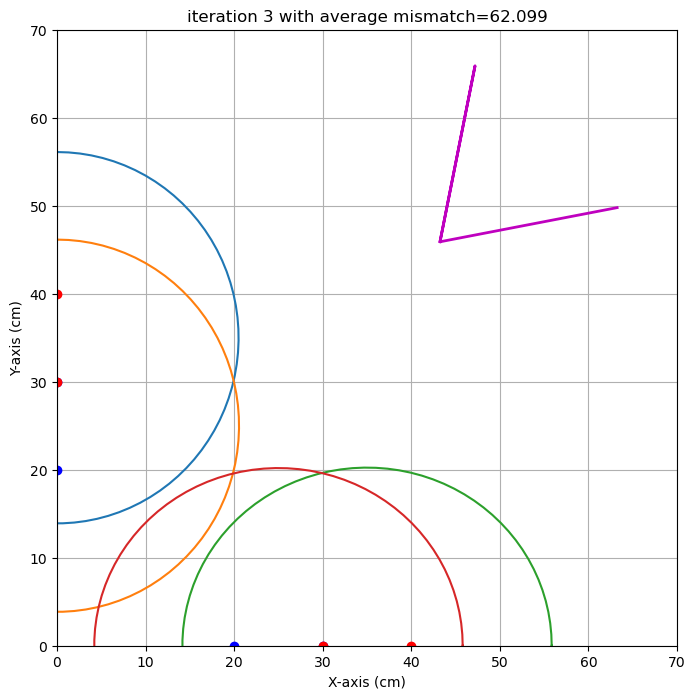

end iteration 3 with average mismatch=62.099


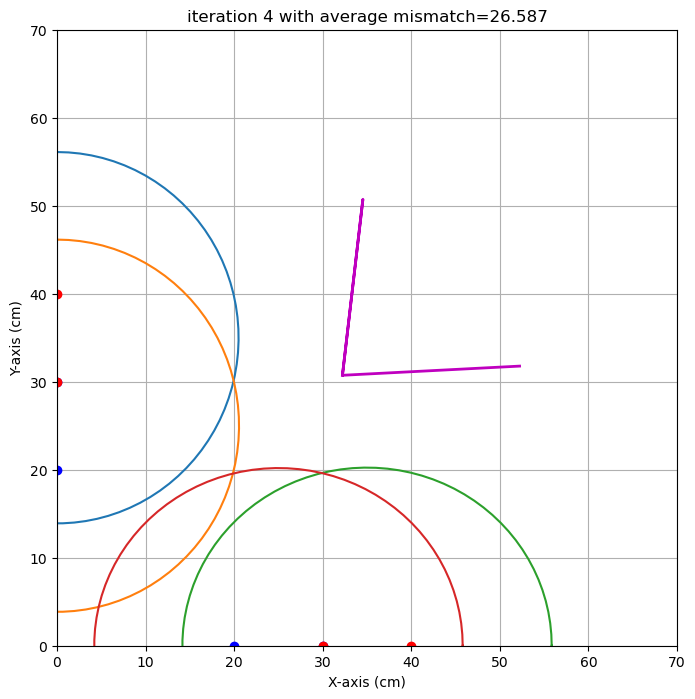

end iteration 4 with average mismatch=26.587


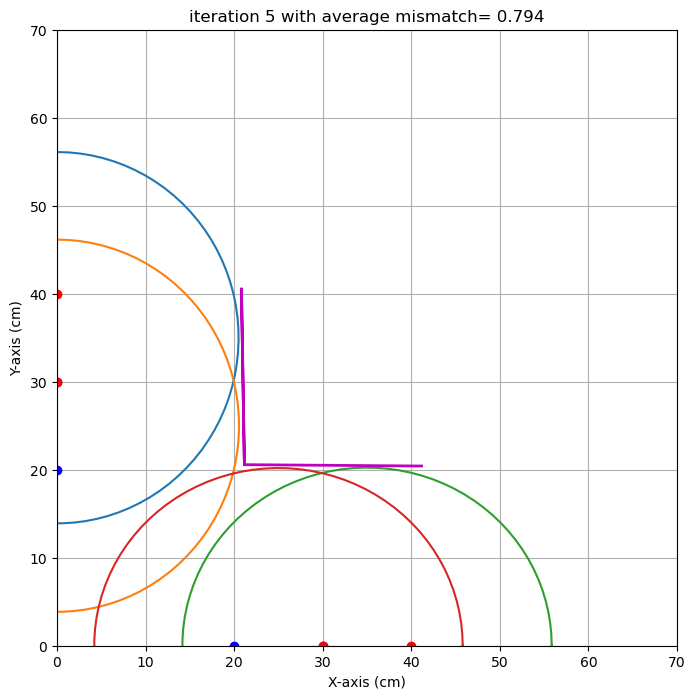

end iteration 5 with average mismatch= 0.794


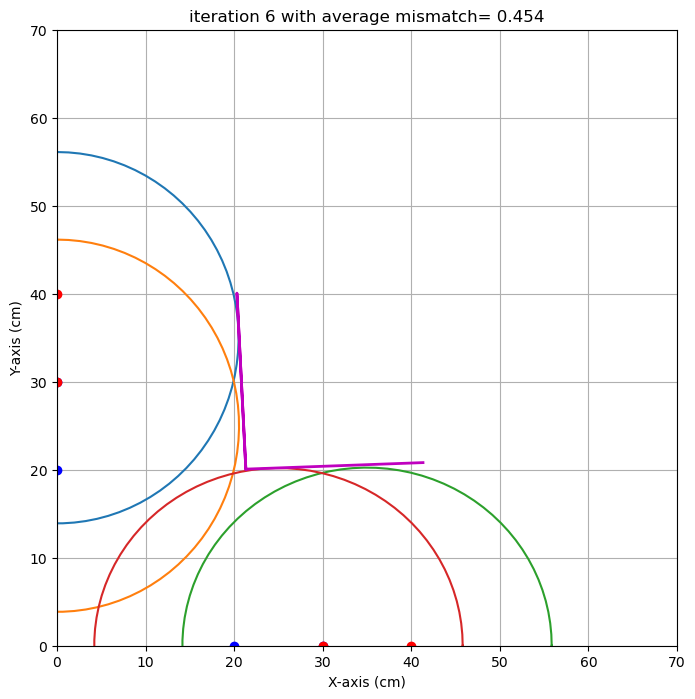

end iteration 6 with average mismatch= 0.454
end iteration 7 with average mismatch= 0.442
end iteration 8 with average mismatch= 0.439
end iteration 9 with average mismatch= 0.438
end iteration 10 with average mismatch= 0.437
end iteration 11 with average mismatch= 0.437
end iteration 12 with average mismatch= 0.437
end iteration 13 with average mismatch= 0.413
end iteration 14 with average mismatch= 0.410
end iteration 15 with average mismatch= 0.409
end iteration 16 with average mismatch= 0.409


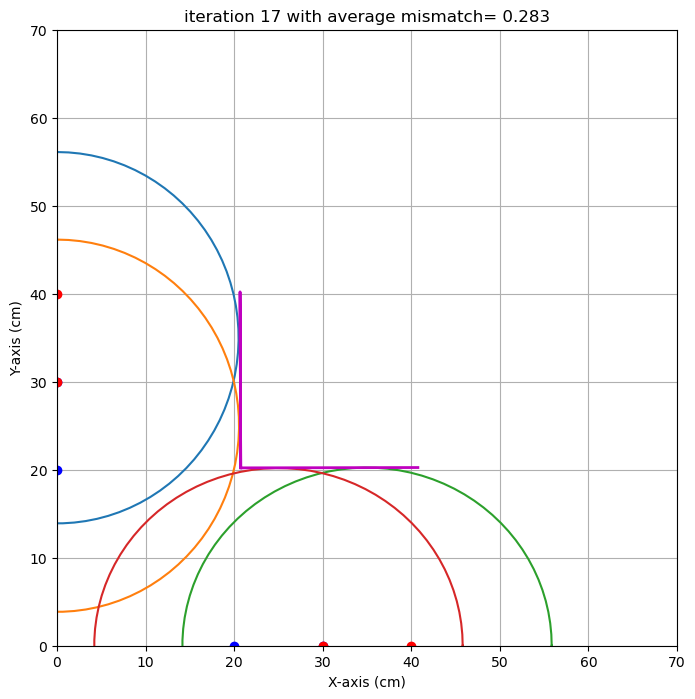

end iteration 17 with average mismatch= 0.283
end iteration 18 with average mismatch= 0.280
end iteration 19 with average mismatch= 0.280
end iteration 20 with average mismatch= 0.280
end iteration 21 with average mismatch= 0.280
end iteration 22 with average mismatch= 0.280
end iteration 23 with average mismatch= 0.280
end iteration 24 with average mismatch= 0.280
end iteration 25 with average mismatch= 0.280
end iteration 26 with average mismatch= 0.280
end iteration 27 with average mismatch= 0.280
end iteration 28 with average mismatch= 0.280
end iteration 29 with average mismatch= 0.280
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.280
###############################################################################
end of iteration  30
Best alpha=   0.11 with uncertainty=   4.49
Best beta =  -0.22 with uncertainty=   5.30
Best x0   =  20.74 with uncertain

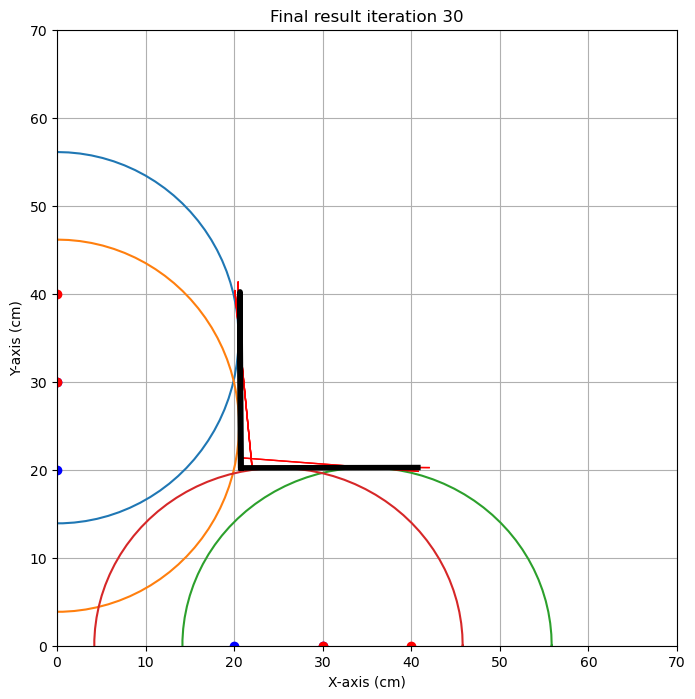

In [42]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42.2],
    [0,30,0,20,42.3],
    #[0,10,0,20,183],
    [40,0,30,0,41.7],
    [30,0,20,0,41.6],
    #[10,0,20,0,155],
    #[10,0,0,10,1.08]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [43]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.7 cm met een standaardafwijking van 1.3 cm 
y0: 20.2 cm met een standaardafwijking van 1.1 cm 
alpha: 0.1 graden met een standaardafwijking van 4.5 graad 
beta: -0.2 graden met een standaardafwijking van 5.3 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Erik van den Berg]
Het eerste algoritme zoekt eerst iteratief op de x-as totdat er een signaal terugkomt. Dan gaat het op basis van de afstand die gevonden is op de y-as zoeken. Als er daar een waarde gevonden wordt, gaat het algoritme 10cm erboven en eronder extra zoeken. Dat doet hij ook bij de x-as vervolgens.
Voeg een foto in van het algoritme van het eerste groepslid
<img src="nogiets.JPG" width="400">

#### algoritme [Félicie van der Leij]
Het tweede algoritme ging systematisch de x-as af; wanneer het reflectieve karton werd gevonden, werden daar extra metingen gedaan om het goed in beeld te brengen. Hetzelfde algoritme is op de y-as toegepast.
Voeg een foto in van het algoritme van het tweede groepslid
<img src="iets.JPG" width="400">

#### algoritme [naam derde student]
Voeg een foto in van het algoritme van het derde groepslid
<img src="IMG_5416.JPG" width="400">

Onze methode kan nooit de positie van een kartonnetje bepalen, dat onder een te scherpe hoek staat t.o.v. een van de assen. Verder kan de positie van het karton niet bepaald worden als het te dicht bij de assen staat.

## Opdracht 6: Test iteratie 0.

In [64]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  31,
           'y0': 37,
           'alpha' : 18,
           'beta' : 6
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Erik van den Berg' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [50,0,70,0,90],
    [0,55,0,35,60],
    [0,50,0,30,61],
    [0,45,0,25,63],
    #[10,0,30,0,145]
    #[50,0,30,0,184]

    ]),
       'Félicie van der Leij' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,0,0,167],
    #[40,0,20,0,140]
    [60,0,40,0,70],
    [50,0,40,0,67],
    [60,0,50,0,71.5],
    [70,0,60,0,76],

    #[0,0,20,0,167],
    [0,40,0,20,70.5],
    [0,35,0,20,70],
    [0,50,0,35,65],
    #[0,60,0,50,170]
    ]),
      }

## Opdracht 7: Evaluatie.

Erik van den Berg
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  70   0  90
1   0  55   0  35  60
2   0  50   0  30  61
3   0  45   0  25  63


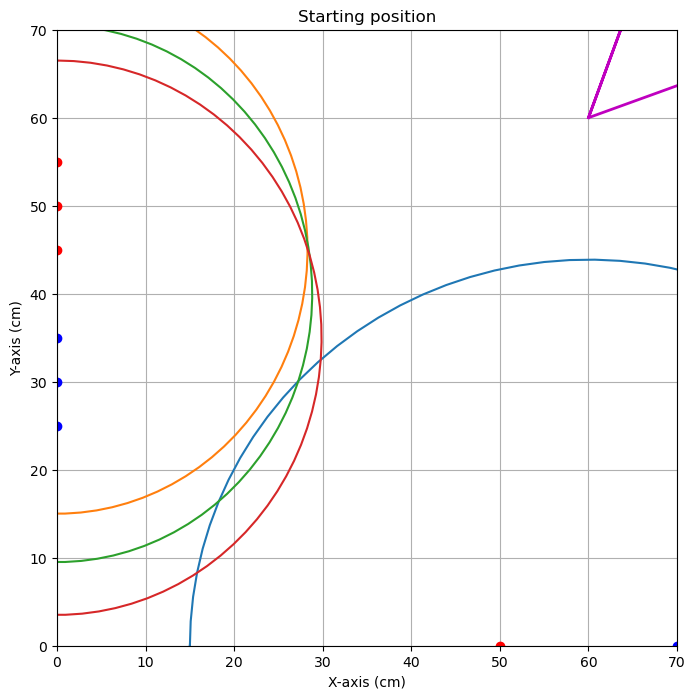


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.456


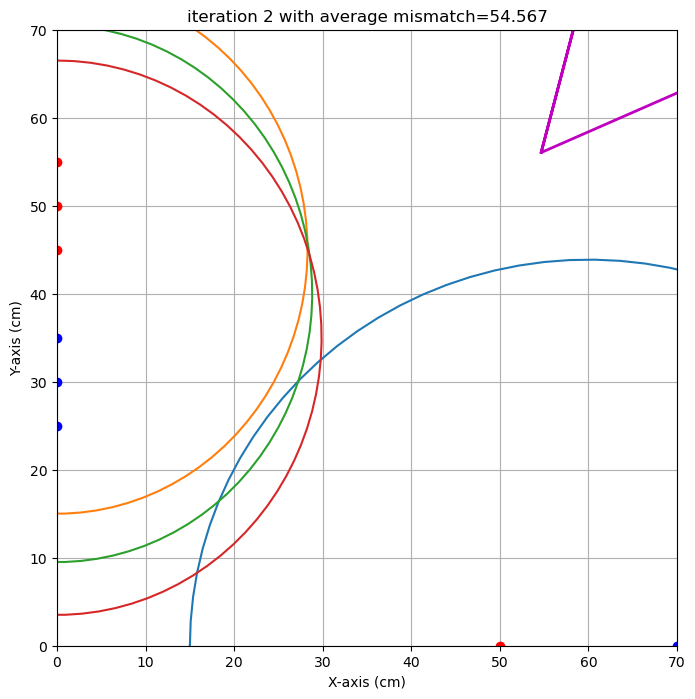

end iteration 2 with average mismatch=54.567


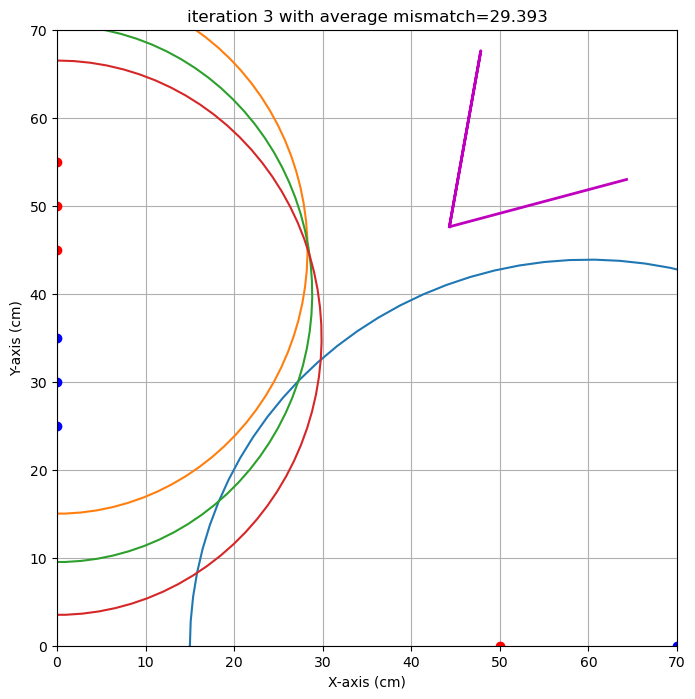

end iteration 3 with average mismatch=29.393


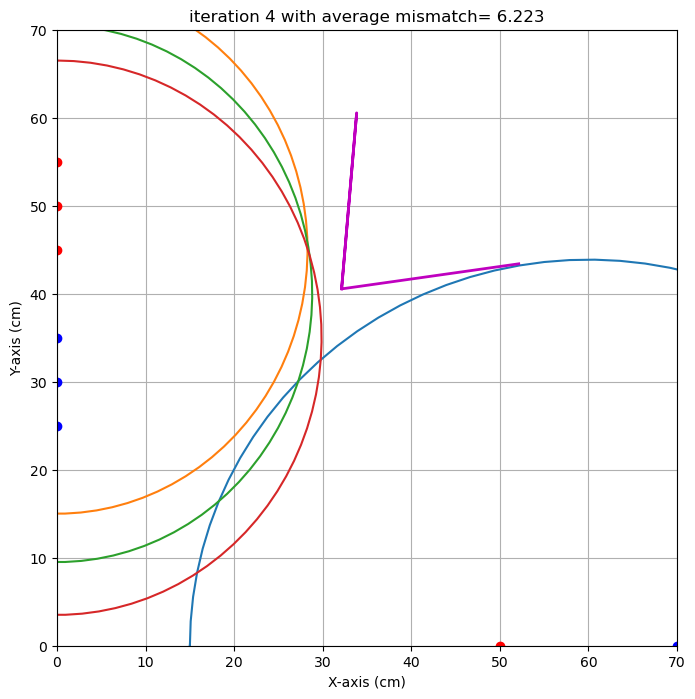

end iteration 4 with average mismatch= 6.223


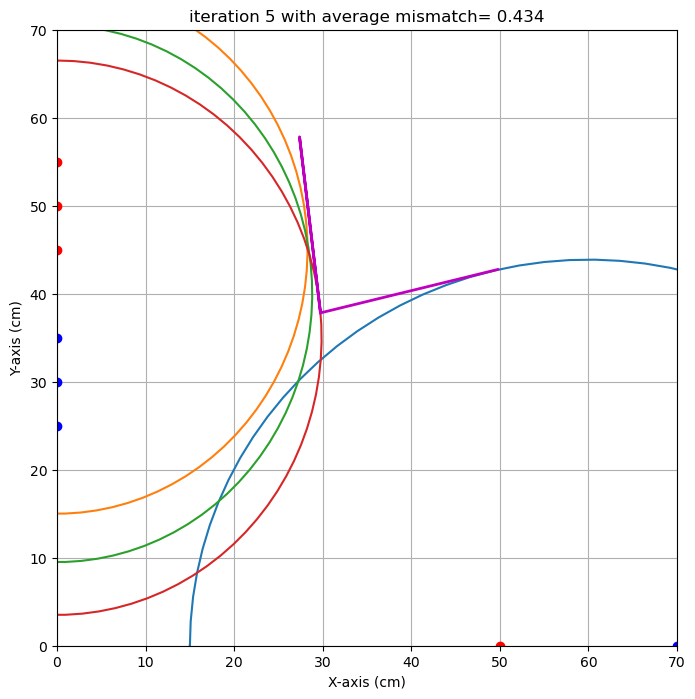

end iteration 5 with average mismatch= 0.434


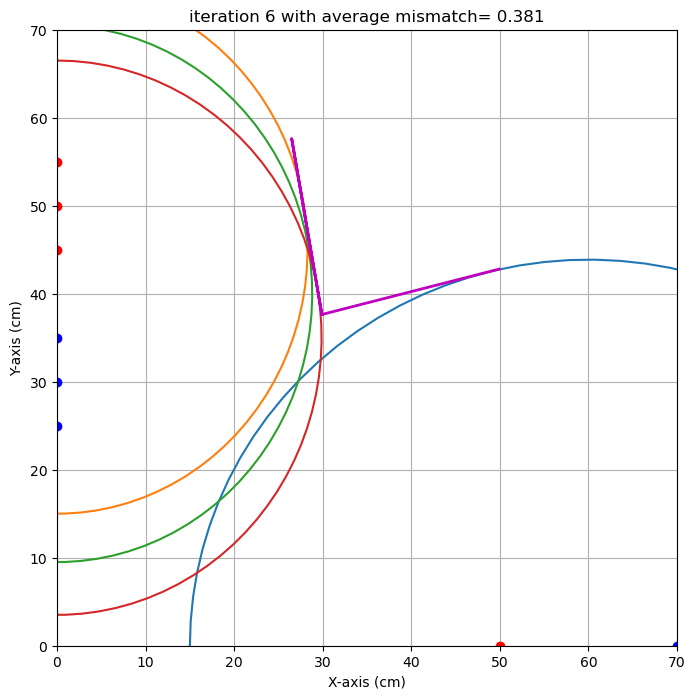

end iteration 6 with average mismatch= 0.381


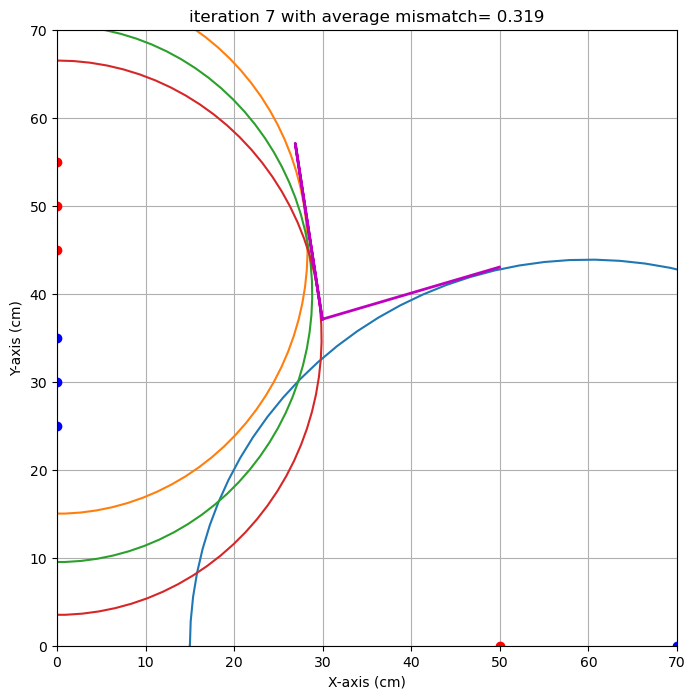

end iteration 7 with average mismatch= 0.319
end iteration 8 with average mismatch= 0.293
end iteration 9 with average mismatch= 0.292
end iteration 10 with average mismatch= 0.291
end iteration 11 with average mismatch= 0.291
end iteration 12 with average mismatch= 0.291
end iteration 13 with average mismatch= 0.291
end iteration 14 with average mismatch= 0.291


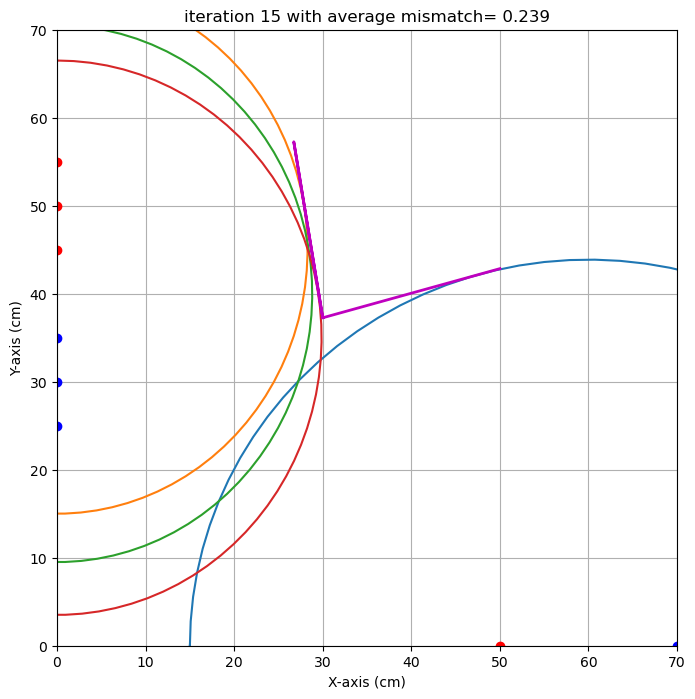

end iteration 15 with average mismatch= 0.239


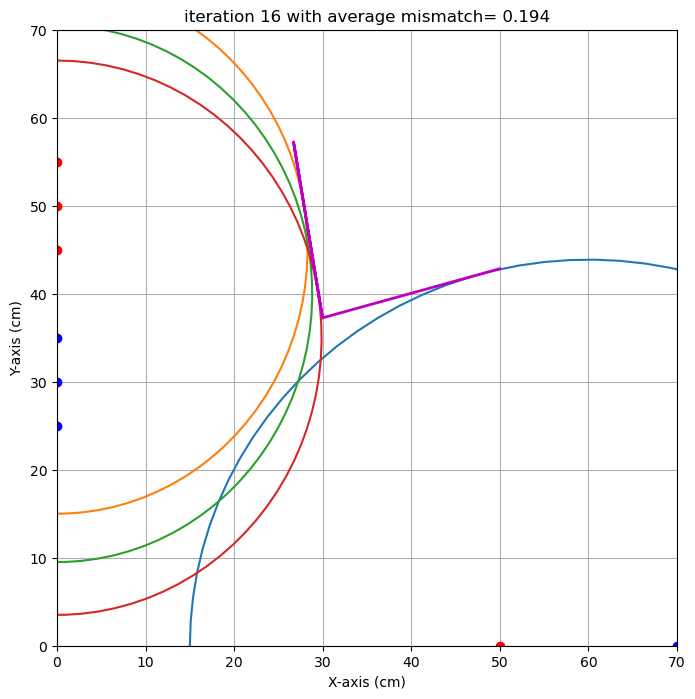

end iteration 16 with average mismatch= 0.194
end iteration 17 with average mismatch= 0.192
end iteration 18 with average mismatch= 0.191
end iteration 19 with average mismatch= 0.191
end iteration 20 with average mismatch= 0.191
end iteration 21 with average mismatch= 0.191
end iteration 22 with average mismatch= 0.191
end iteration 23 with average mismatch= 0.191
end iteration 24 with average mismatch= 0.191
end iteration 25 with average mismatch= 0.191
end iteration 26 with average mismatch= 0.191
end iteration 27 with average mismatch= 0.191
end iteration 28 with average mismatch= 0.191
end iteration 29 with average mismatch= 0.191
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.191
###############################################################################
end of iteration  30
Best alpha=  15.59 with uncertainty=   9.26
Best beta =  -9.30 with uncerta

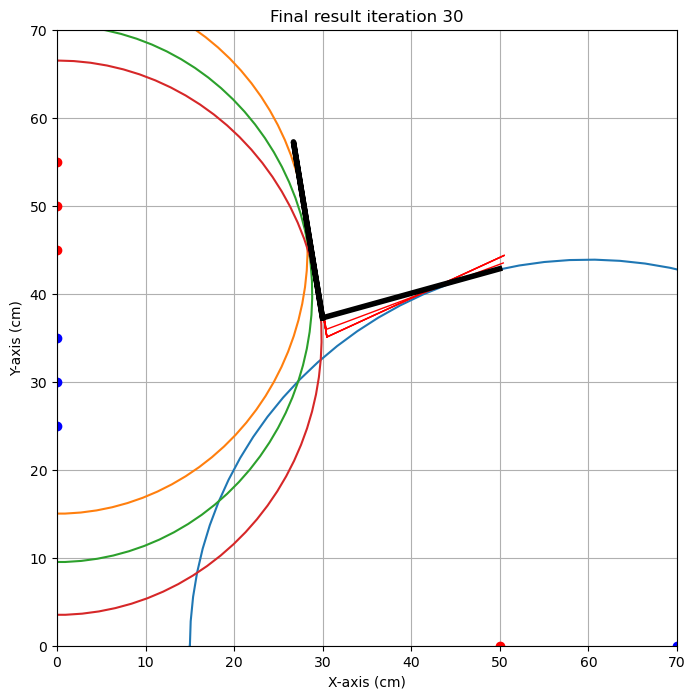

{'alpha': 15.587364254013975, 'alpha_eps': 9.255263879486117, 'beta': -9.304754639269104, 'beta_eps': 0.4123006444146178, 'x0': 29.970554595147348, 'x0_eps': 0.49954239801146016, 'y0': 37.25564951615773, 'y0_eps': 2.1698647890324807}
Félicie van der Leij
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  60   0  40   0  70.0
1  50   0  40   0  67.0
2  60   0  50   0  71.5
3  70   0  60   0  76.0
4   0  40   0  20  70.5
5   0  35   0  20  70.0
6   0  50   0  35  65.0


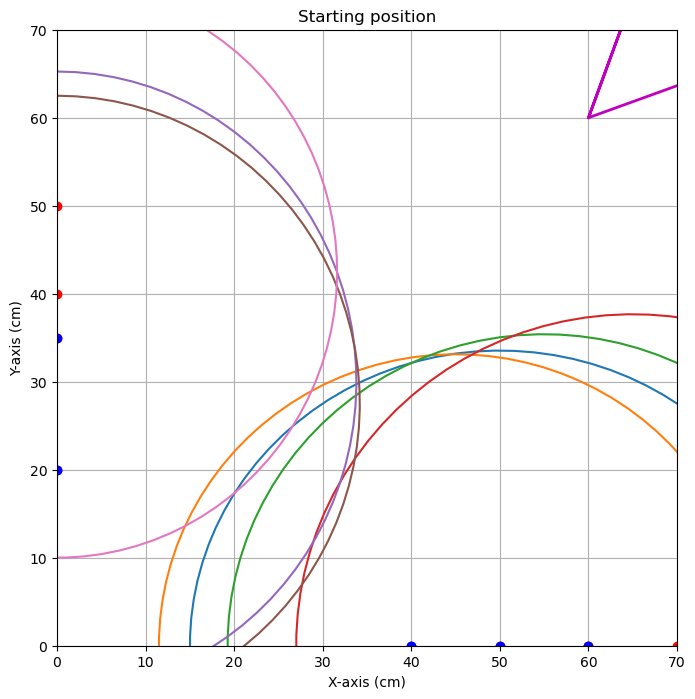


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.026


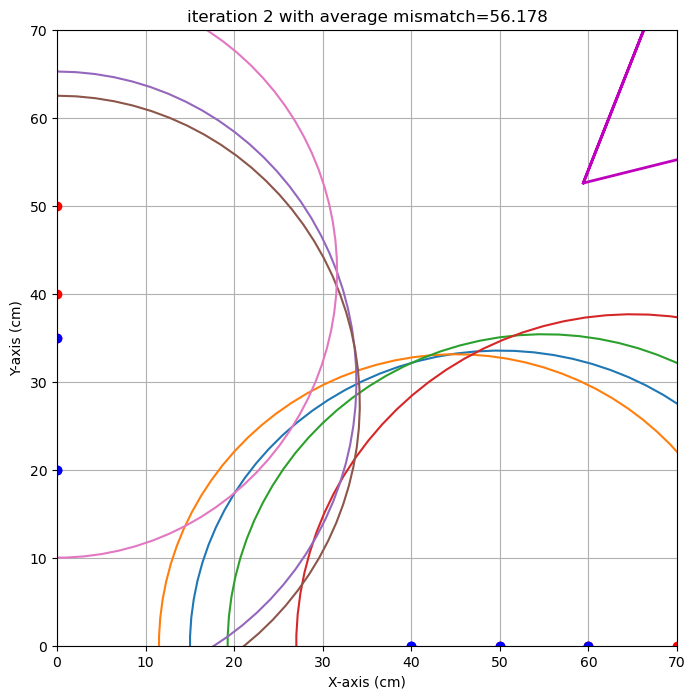

end iteration 2 with average mismatch=56.178


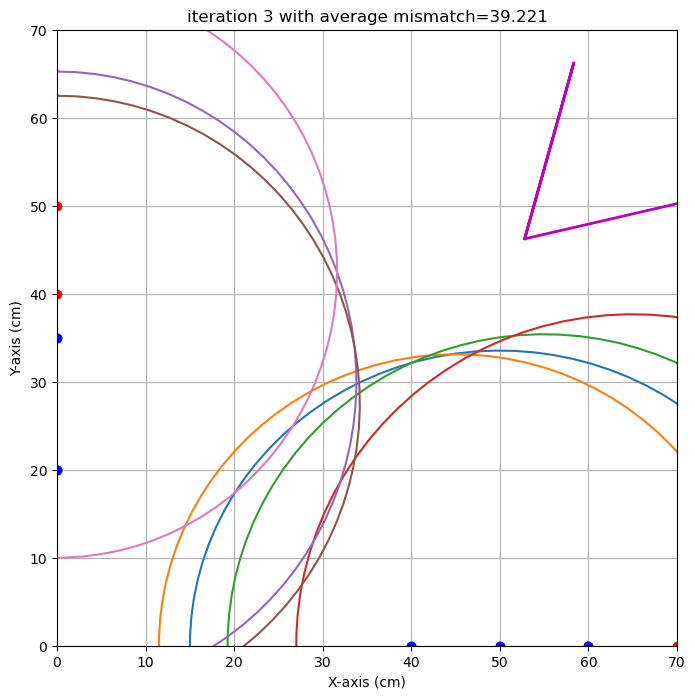

end iteration 3 with average mismatch=39.221


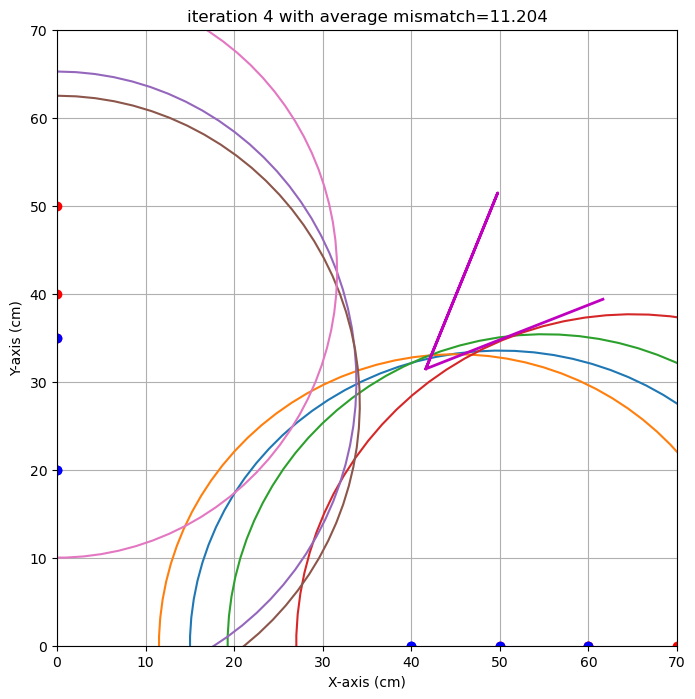

end iteration 4 with average mismatch=11.204


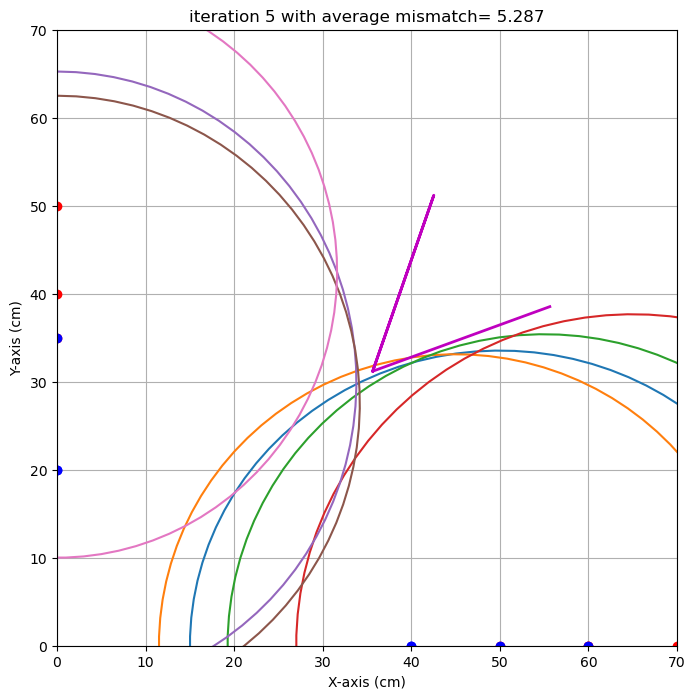

end iteration 5 with average mismatch= 5.287


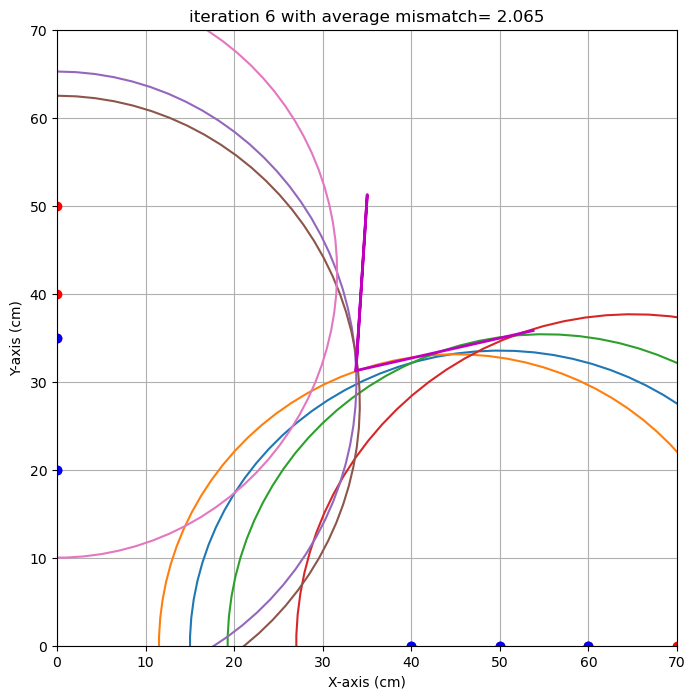

end iteration 6 with average mismatch= 2.065


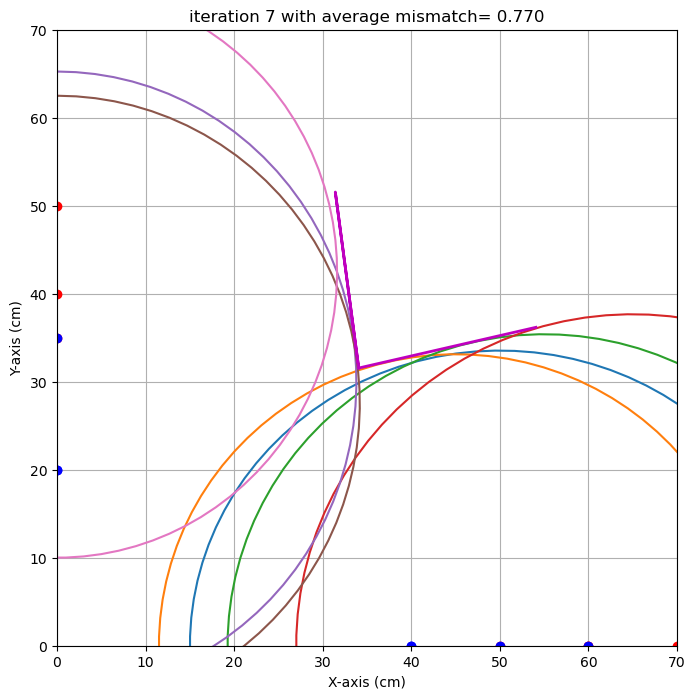

end iteration 7 with average mismatch= 0.770
end iteration 8 with average mismatch= 0.727


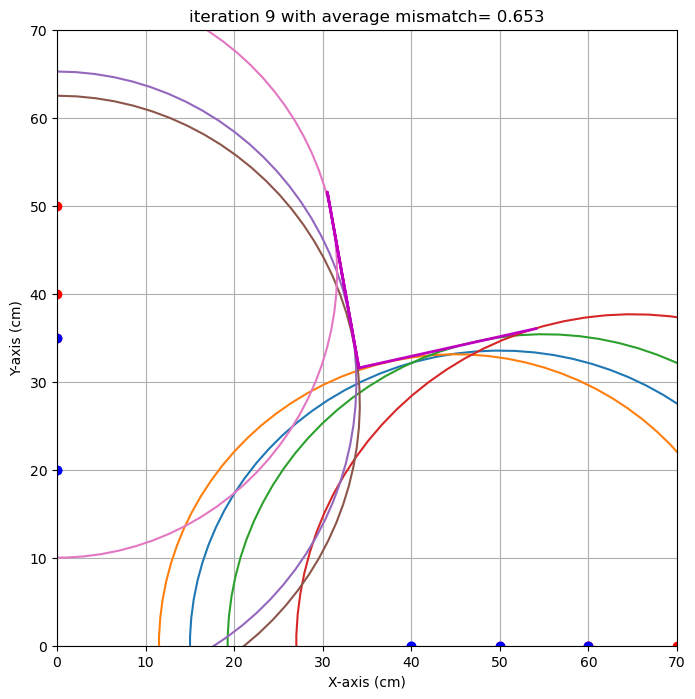

end iteration 9 with average mismatch= 0.653
end iteration 10 with average mismatch= 0.612


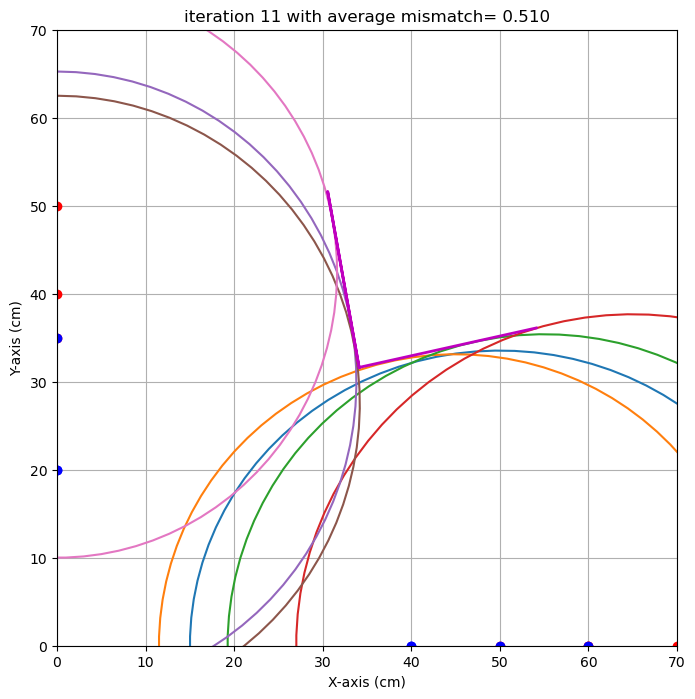

end iteration 11 with average mismatch= 0.510
end iteration 12 with average mismatch= 0.486
end iteration 13 with average mismatch= 0.477
end iteration 14 with average mismatch= 0.475
end iteration 15 with average mismatch= 0.475
end iteration 16 with average mismatch= 0.475
end iteration 17 with average mismatch= 0.475
end iteration 18 with average mismatch= 0.475
end iteration 19 with average mismatch= 0.475
end iteration 20 with average mismatch= 0.475
end iteration 21 with average mismatch= 0.475
end iteration 22 with average mismatch= 0.475
end iteration 23 with average mismatch= 0.475
end iteration 24 with average mismatch= 0.475
end iteration 25 with average mismatch= 0.475
end iteration 26 with average mismatch= 0.475
end iteration 27 with average mismatch= 0.475
end iteration 28 with average mismatch= 0.475
end iteration 29 with average mismatch= 0.475
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

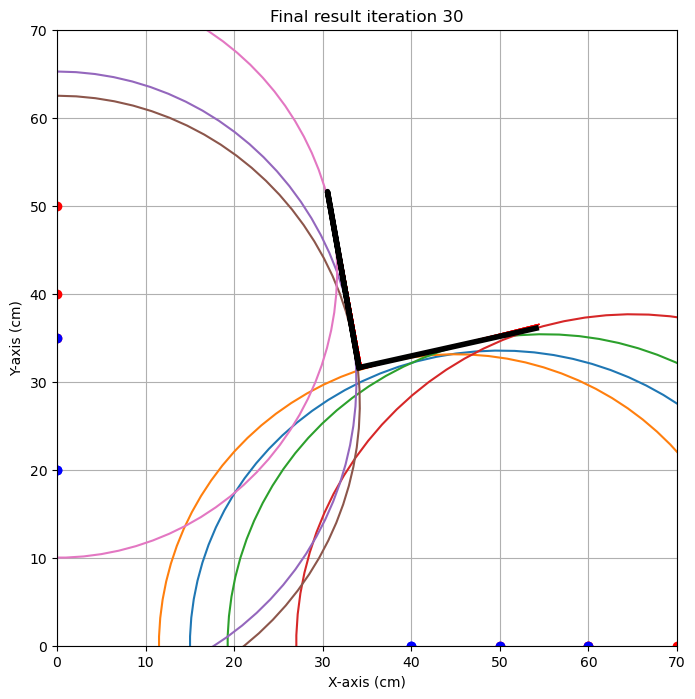

{'alpha': 12.621241733127906, 'alpha_eps': 1.562881114769656, 'beta': -10.07892200344698, 'beta_eps': 0.30878893000671503, 'x0': 34.08997626671691, 'x0_eps': 0.3030289642326238, 'y0': 31.603291326302536, 'y0_eps': 0.14824474463760495}
Luc van der Wilt


KeyError: 'Luc van der Wilt'

In [65]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [66]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Erik van den Berg 
x0 target is : 31.0. Gevonden waarde: 30.0 cm met een standaardafwijking van 0.5 cm 
y0 target is : 37.0. Gevonden waarde: 37.3 cm met een standaardafwijking van 2.2 cm 
alpha target is : 18.0. Gevonden waarde: 15.6 graden met een standaardafwijking van 9.3 graad 
beta target is : 6.0. Gevonden waarde: -9.3 graden met een standaardafwijking van 0.4 graad 

Félicie van der Leij 
x0 target is : 31.0. Gevonden waarde: 34.1 cm met een standaardafwijking van 0.3 cm 
y0 target is : 37.0. Gevonden waarde: 31.6 cm met een standaardafwijking van 0.1 cm 
alpha target is : 18.0. Gevonden waarde: 12.6 graden met een standaardafwijking van 1.6 graad 
beta target is : 6.0. Gevonden waarde: -10.1 graden met een standaardafwijking van 0.3 graad 



KeyError: 'Luc van der Wilt'

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](nognogiets.jpeg)


Er zijn extra metingen uitgevoerd tussendoor, waarbij de reflector is verplaatst en op verschillende hoeken gezet, en de sensoren zijn verplaatst om te testen of het algoritme er beter bij zou gaan werken. We hebben hardop overlegd over andere manieren om de sensors te plaatsen en bij het uitspreken zijn we er achtergekomen dat die niet zouden werken. Uit onze eerste resultaten blijkt dat de 2 eerste algoritmes voldoen aan de eisen (Kleine afwijking in Félicie's resultaten door per ongelukkige verplaatsing van de reflector). De algoritme van Félicie is makkelijker uit te voeren en niet deels gebaseerd op een gok. We hebben aan het einde alleen nog de waardes van de laatste algoritme blok veranderd omdat we er achter zijn gekomen dat het niet paste om de sensors zo dicht op elkaar de zetten. Uit deze iteraties blijkt dat de oorspronkelijke algoritme (van Félicie) de beste is. 

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  60   0  40   0  76
1  50   0  40   0  71
2  60   0  50   0  80
3  70   0  60   0  91
4   0  20   0   0  56
5   0  15   0   0  58
6   0  30   0  15  43
7   0  40   0  30  30


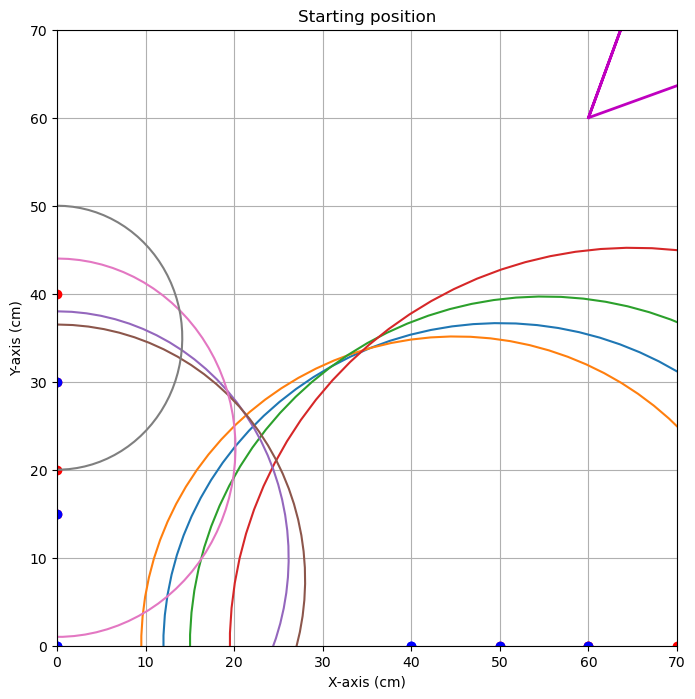


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.269


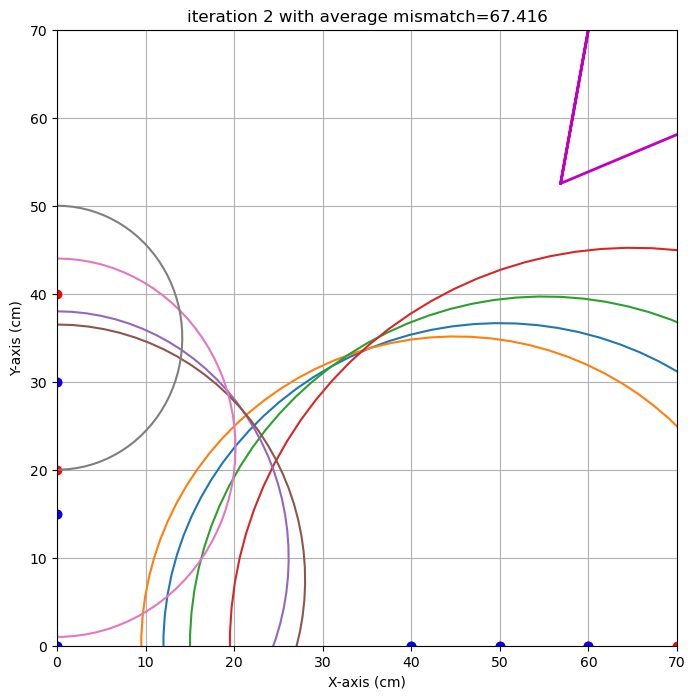

end iteration 2 with average mismatch=67.416


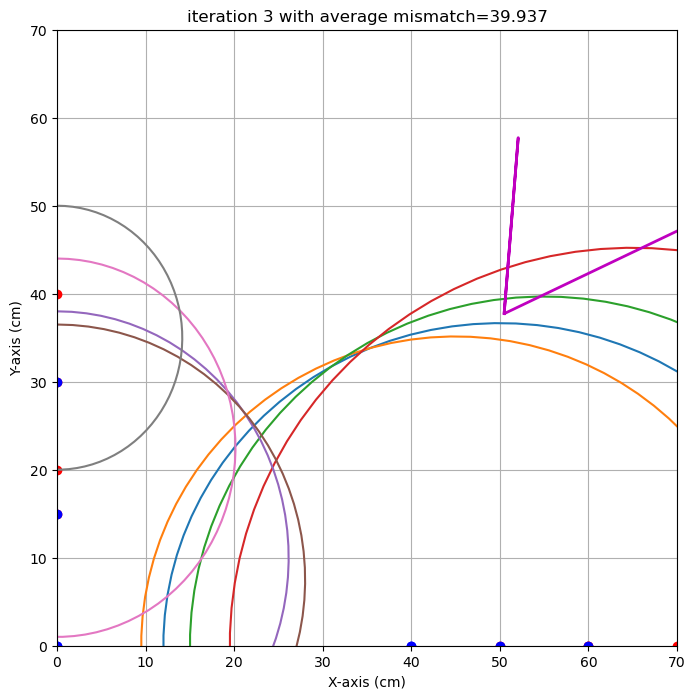

end iteration 3 with average mismatch=39.937


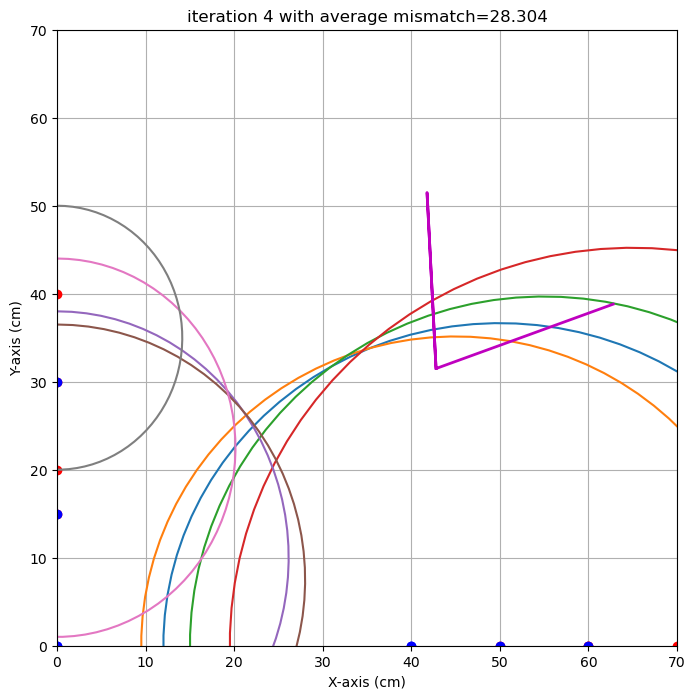

end iteration 4 with average mismatch=28.304


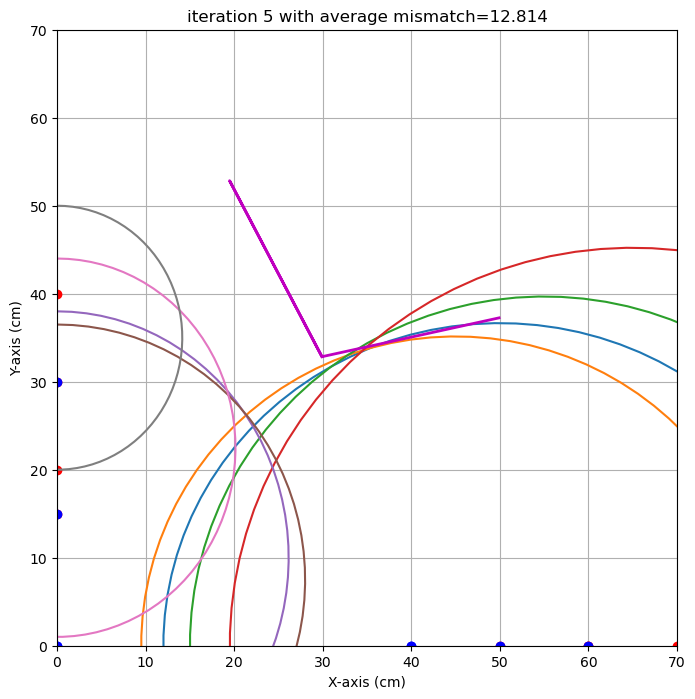

end iteration 5 with average mismatch=12.814


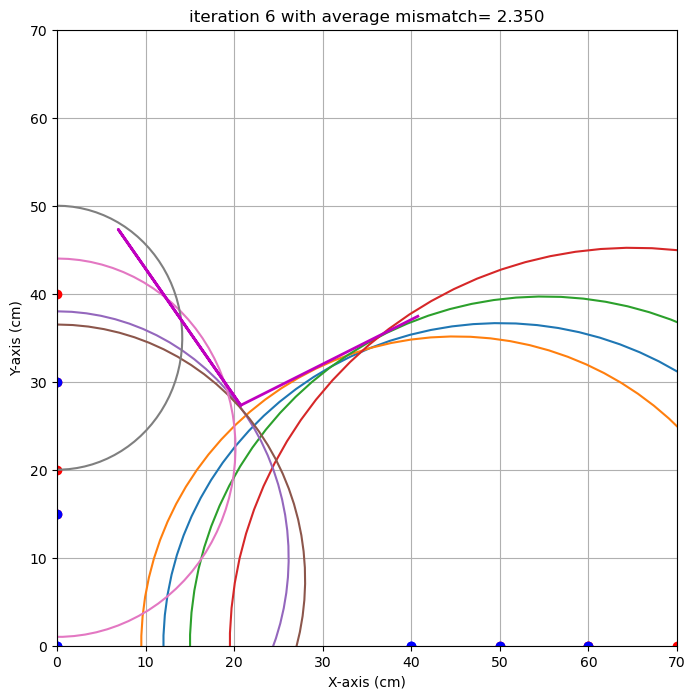

end iteration 6 with average mismatch= 2.350


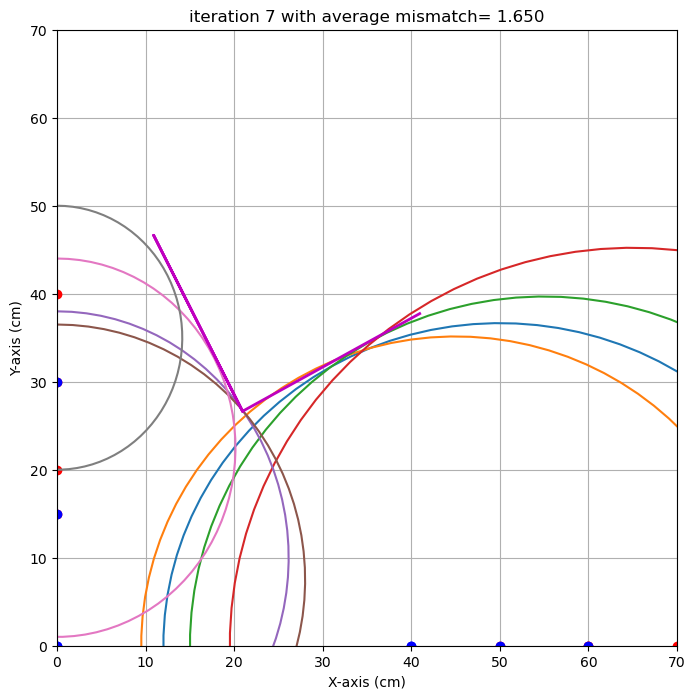

end iteration 7 with average mismatch= 1.650


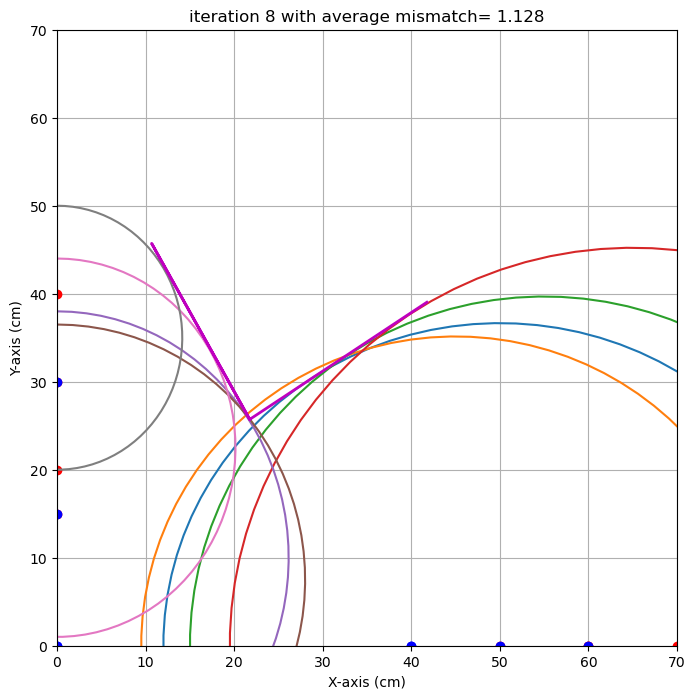

end iteration 8 with average mismatch= 1.128
end iteration 9 with average mismatch= 1.045
end iteration 10 with average mismatch= 1.040
end iteration 11 with average mismatch= 1.040
end iteration 12 with average mismatch= 1.040
end iteration 13 with average mismatch= 1.040
end iteration 14 with average mismatch= 1.040
end iteration 15 with average mismatch= 1.040
end iteration 16 with average mismatch= 1.040
end iteration 17 with average mismatch= 1.040
end iteration 18 with average mismatch= 1.040
end iteration 19 with average mismatch= 1.040
end iteration 20 with average mismatch= 1.040
end iteration 21 with average mismatch= 1.040
end iteration 22 with average mismatch= 1.040
end iteration 23 with average mismatch= 1.040
end iteration 24 with average mismatch= 1.040
end iteration 25 with average mismatch= 1.040
end iteration 26 with average mismatch= 1.040
end iteration 27 with average mismatch= 1.040
end iteration 28 with average mismatch= 1.040
end iteration 29 with average mismat

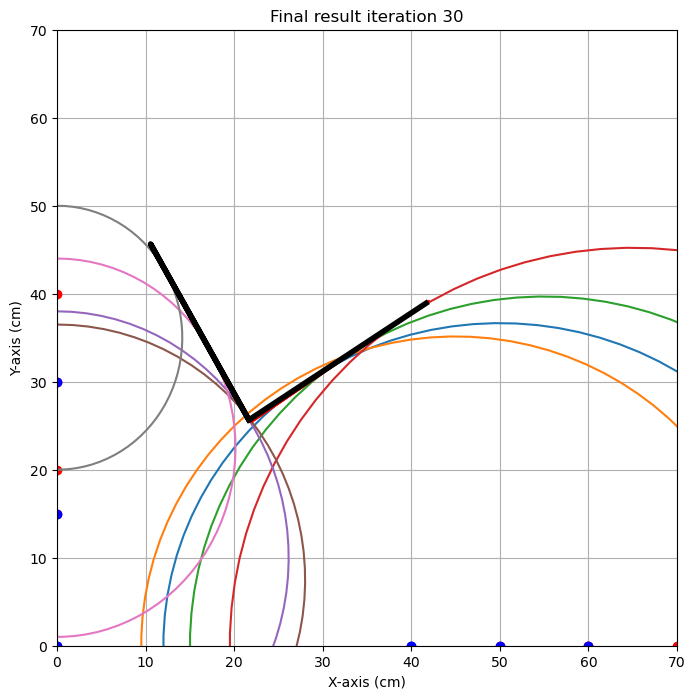

{'alpha': 33.55465560750389, 'alpha_eps': 1.0304121514792541, 'beta': -29.02800689598372, 'beta_eps': 0.4975861855137076, 'x0': 21.661449599173345, 'x0_eps': 0.309689294221954, 'y0': 25.653125642276894, 'y0_eps': 0.2503972296293604}
locatie 1 
x0 target is : 20.0. Gevonden waarde: 21.7 cm met een standaardafwijking van 0.3 cm 
y0 target is : 23.0. Gevonden waarde: 25.7 cm met een standaardafwijking van 0.3 cm 
alpha target is : 42.0. Gevonden waarde: 33.6 graden met een standaardafwijking van 1.0 graad 
beta target is : 30.0. Gevonden waarde: -29.0 graden met een standaardafwijking van 0.5 graad 



In [67]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 20,
                    'y0':23,
                    'alpha' : 42,
                    'beta' : 30}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,0,0,0],
    #[40,0,20,0,0],
    [60,0,40,0,76],
    [50,0,40,0,71],
    [60,0,50,0,80],
    [70,0,60,0,91],
    [0,20,0,0,56],
    [0,15,0,0,58],
    [0,30,0,15,43],
    [0,40,0,30,30]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  70   0  60   0  89
1  60   0  50   0  79
2  65   0  55   0  83
3  70   0  55   0  87
4   0  40   0  20  58
5   0  35   0  20  58
6   0  50   0  35  49


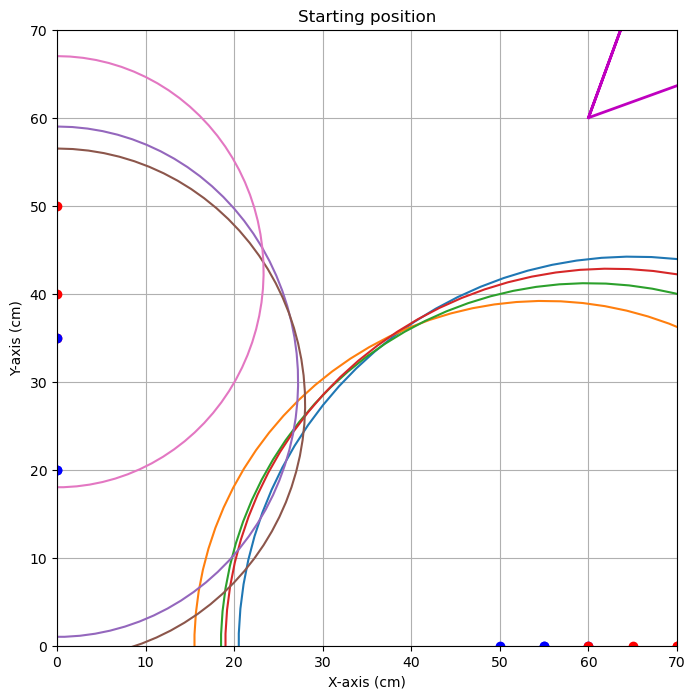


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.224


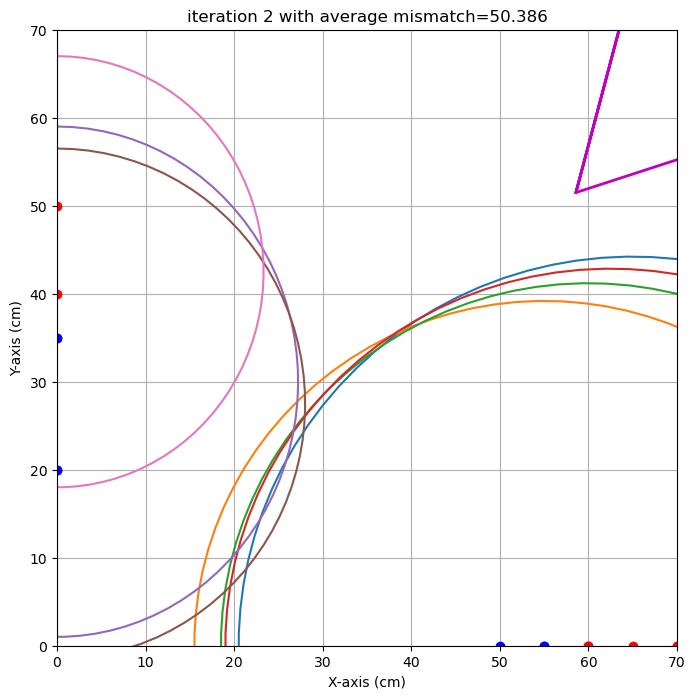

end iteration 2 with average mismatch=50.386


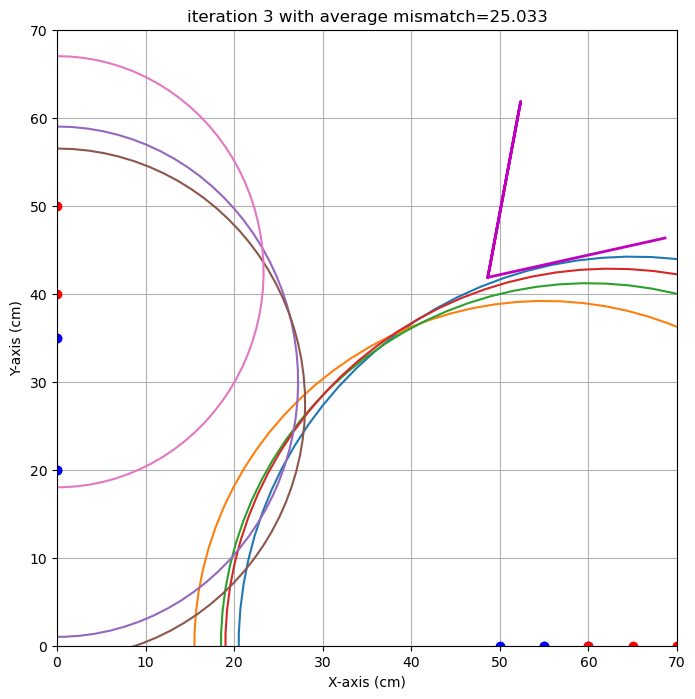

end iteration 3 with average mismatch=25.033


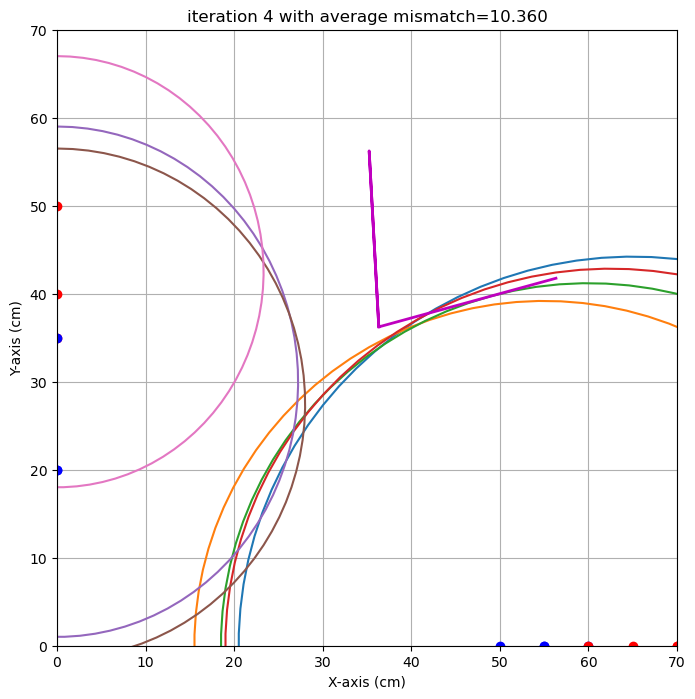

end iteration 4 with average mismatch=10.360


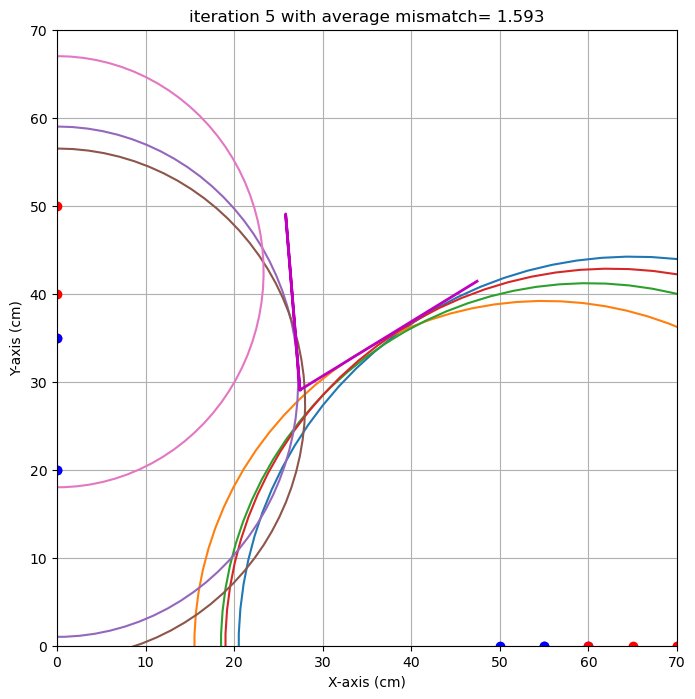

end iteration 5 with average mismatch= 1.593
end iteration 6 with average mismatch= 1.534


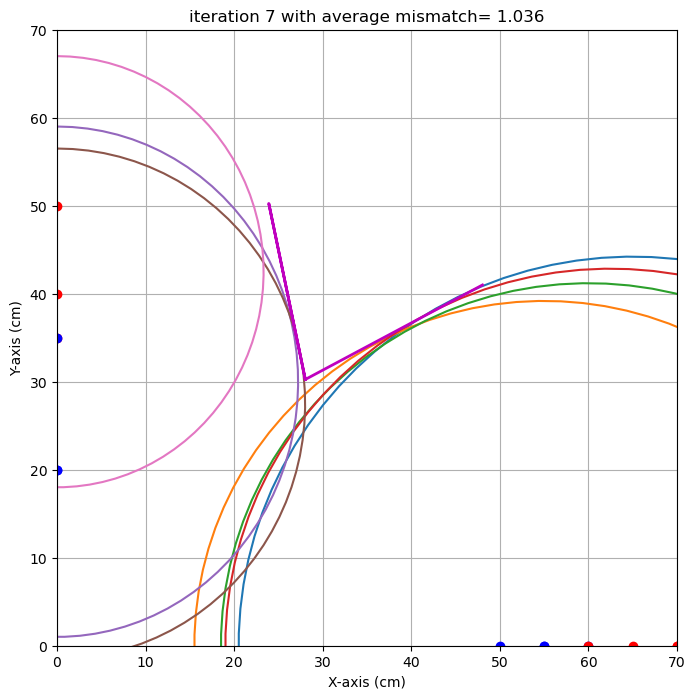

end iteration 7 with average mismatch= 1.036


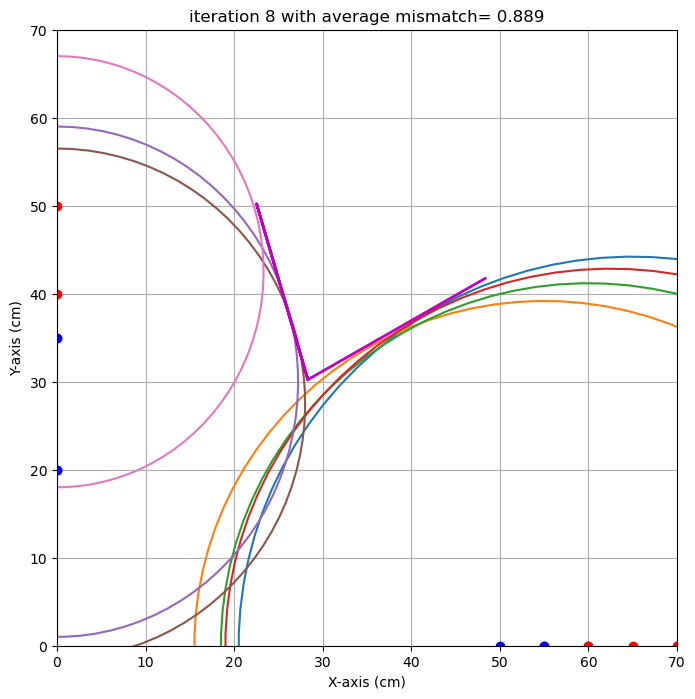

end iteration 8 with average mismatch= 0.889


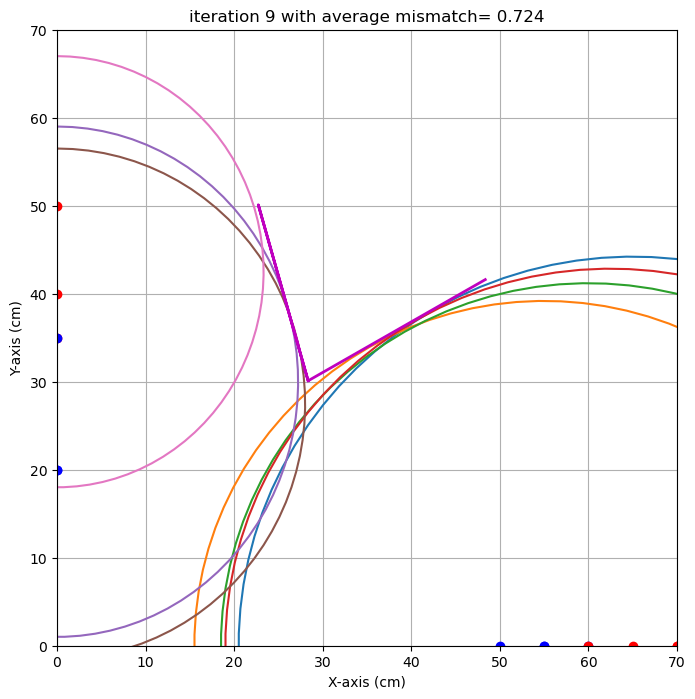

end iteration 9 with average mismatch= 0.724


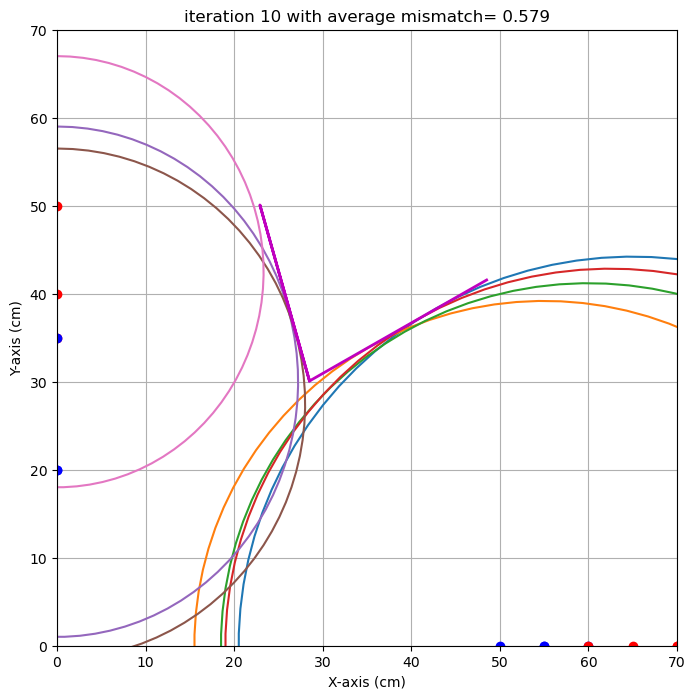

end iteration 10 with average mismatch= 0.579


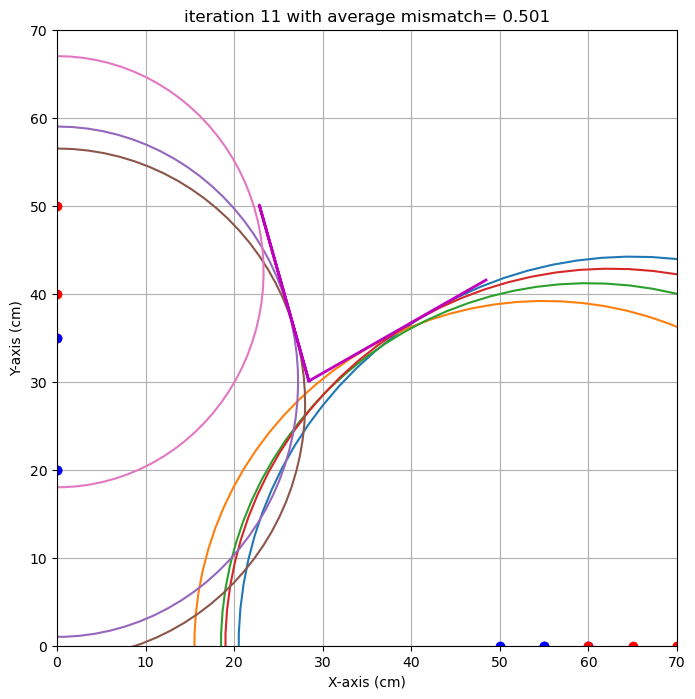

end iteration 11 with average mismatch= 0.501
end iteration 12 with average mismatch= 0.501
end iteration 13 with average mismatch= 0.501
end iteration 14 with average mismatch= 0.501
end iteration 15 with average mismatch= 0.501
end iteration 16 with average mismatch= 0.501
end iteration 17 with average mismatch= 0.501
end iteration 18 with average mismatch= 0.501
end iteration 19 with average mismatch= 0.501
end iteration 20 with average mismatch= 0.501
end iteration 21 with average mismatch= 0.501


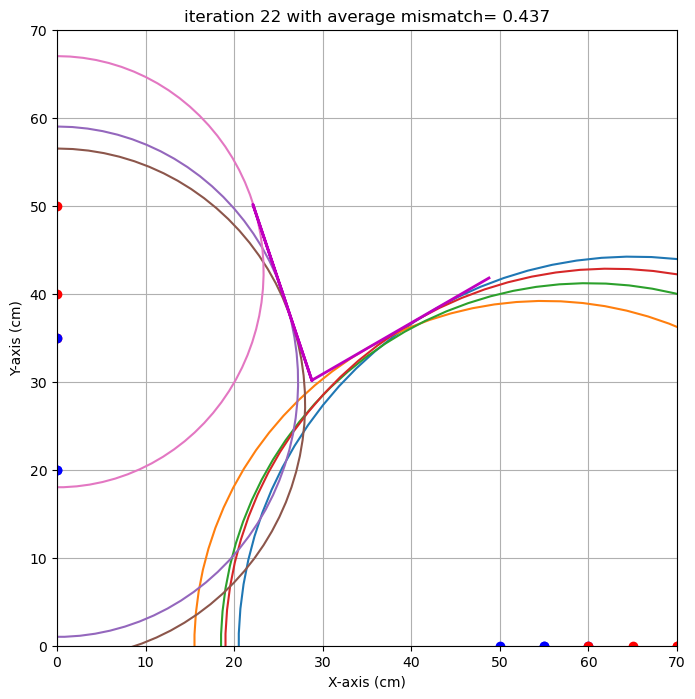

end iteration 22 with average mismatch= 0.437
end iteration 23 with average mismatch= 0.437
end iteration 24 with average mismatch= 0.437
end iteration 25 with average mismatch= 0.437
end iteration 26 with average mismatch= 0.437
end iteration 27 with average mismatch= 0.437
end iteration 28 with average mismatch= 0.437
end iteration 29 with average mismatch= 0.437
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.437
###############################################################################
end of iteration  30
Best alpha=  30.17 with uncertainty=   0.42
Best beta = -18.41 with uncertainty=   3.64
Best x0   =  28.77 with uncertainty=   0.52
Best y0   =  30.16 with uncertainty=   0.38
###############################################################################


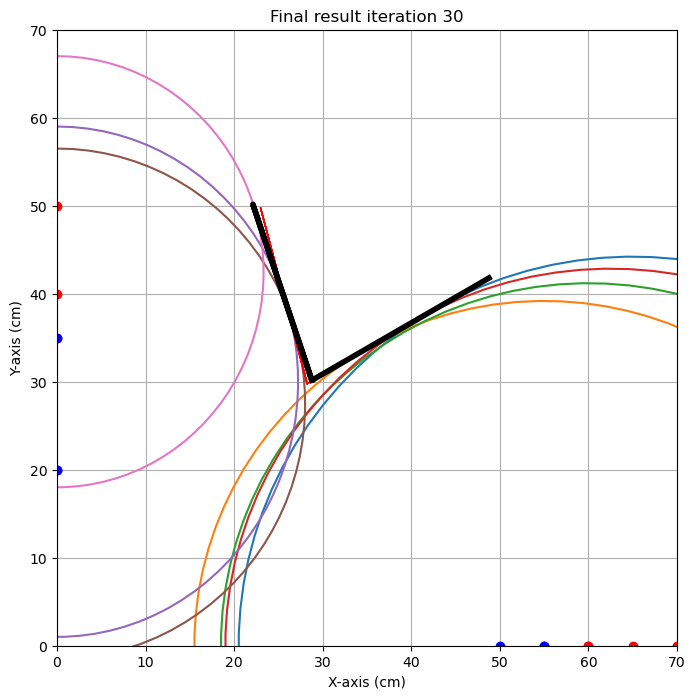

{'alpha': 30.170261146541993, 'alpha_eps': 0.4189579920710429, 'beta': -18.413624423819815, 'beta_eps': 3.644893439029401, 'x0': 28.768033800711258, 'x0_eps': 0.5236770941596518, 'y0': 30.16090807928364, 'y0_eps': 0.384024345957787}
test locatie 
x0 target is : 28.0. Gevonden waarde: 28.8 cm met een standaardafwijking van 0.5 cm 
y0 target is : 29.5. Gevonden waarde: 30.2 cm met een standaardafwijking van 0.4 cm 
alpha target is : 35.0. Gevonden waarde: 30.2 graden met een standaardafwijking van 0.4 graad 
beta target is : -22.0. Gevonden waarde: -18.4 graden met een standaardafwijking van 3.6 graad 



In [73]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  28,
                    'y0':  29.5,
                    'alpha' : 35,
                    'beta' :  -22
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,0,0,145],
    #[40,0,20,0,155],
    #[60,0,40,0,150],
    [70,0,60,0,89],
    [60,0,50,0,79],
    [65,0,55,0,83],
    [70,0,55,0,87],
    #[0,20,0,0,160],
    [0,40,0,20,58],
    [0,35,0,20,58],
    [0,50,0,35,49],
    #[0,60,0,50,160]
    ])
      }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Eerste versie

Figuur: ![Alt](iets.JPG "Title")

Tweede versie

Figuur: ![Alt](nognogiets.jpeg "Title")

Er zijn extra metingen uitgevoerd tussendoor, waarbij de reflector is verplaatst en op verschillende hoeken gezet, en de sensoren zijn verplaatst om te testen of het algoritme er beter bij zou gaan werken. We hebben hardop overlegd over andere manieren om de sensors te plaatsen en bij het uitspreken zijn we er achtergekomen dat die niet zouden werken. Uit onze eerste resultaten blijkt dat de 2 eerste algoritmes voldoen aan de eisen (Kleine afwijking in Félicie's resultaten door per ongelukkige verplaatsing van de reflector). De algoritme van Félicie is makkelijker uit te voeren en niet deels gebaseerd op een gok. We hebben aan het einde alleen nog de waardes van de laatste algoritme blok veranderd omdat we er achter zijn gekomen dat het niet paste om de sensors zo dicht op elkaar de zetten. Uit deze iteraties blijkt dat de oorspronkelijke algoritme (van Félicie) de beste is. 